<a href="https://colab.research.google.com/github/jatinvandranki/Banking-Interface/blob/main/StockMarket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install pandas scikit-learn matplotlib seaborn


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("train_stockemo.csv")

# Clean text column
df["text"] = df["processed"].fillna("")

# Drop rows with empty labels if any
df = df[df["emo_label"].notna()]

# Use 'emo_label' as target for emotion classification
X = df["text"]
y = df["emo_label"]


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)

# Predict
y_pred = clf.predict(X_test_tfidf)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.373125
Classification Report:
               precision    recall  f1-score   support

   ambiguous       0.27      0.12      0.17       146
   amusement       0.43      0.27      0.33       147
       anger       0.48      0.15      0.23        66
     anxiety       0.34      0.50      0.41       206
      belief       0.40      0.30      0.34       122
   confusion       0.78      0.45      0.57       101
  depression       0.67      0.31      0.42        39
     disgust       0.36      0.58      0.44       208
  excitement       0.41      0.36      0.38       230
    optimism       0.30      0.49      0.37       250
       panic       0.62      0.16      0.25        51
    surprise       0.50      0.03      0.06        34

    accuracy                           0.37      1600
   macro avg       0.46      0.31      0.33      1600
weighted avg       0.41      0.37      0.36      1600



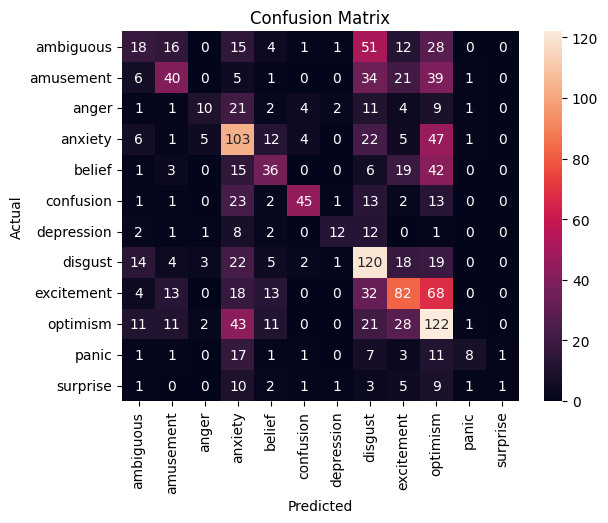

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [8]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the model
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluate
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.34375
SVM Classification Report:
               precision    recall  f1-score   support

   ambiguous       0.22      0.18      0.20       146
   amusement       0.31      0.23      0.26       147
       anger       0.32      0.20      0.24        66
     anxiety       0.34      0.38      0.36       206
      belief       0.29      0.34      0.32       122
   confusion       0.56      0.50      0.52       101
  depression       0.57      0.33      0.42        39
     disgust       0.34      0.43      0.38       208
  excitement       0.37      0.34      0.36       230
    optimism       0.34      0.42      0.37       250
       panic       0.36      0.24      0.29        51
    surprise       0.35      0.21      0.26        34

    accuracy                           0.34      1600
   macro avg       0.36      0.32      0.33      1600
weighted avg       0.35      0.34      0.34      1600



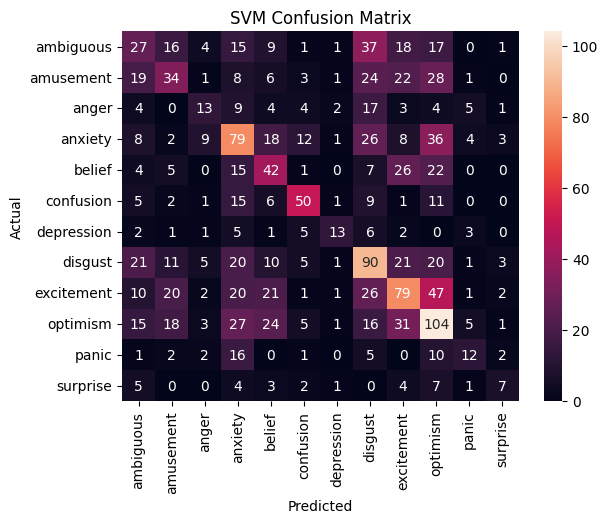

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)
sns.heatmap(cm_svm, annot=True, fmt="d", xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()



In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluate
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.305
Naive Bayes Classification Report:
               precision    recall  f1-score   support

   ambiguous       0.43      0.02      0.04       146
   amusement       0.30      0.02      0.04       147
       anger       1.00      0.02      0.03        66
     anxiety       0.35      0.49      0.41       206
      belief       0.18      0.02      0.03       122
   confusion       1.00      0.20      0.33       101
  depression       0.00      0.00      0.00        39
     disgust       0.31      0.68      0.42       208
  excitement       0.36      0.27      0.31       230
    optimism       0.24      0.62      0.35       250
       panic       1.00      0.04      0.08        51
    surprise       0.00      0.00      0.00        34

    accuracy                           0.30      1600
   macro avg       0.43      0.20      0.17      1600
weighted avg       0.39      0.30      0.24      1600



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


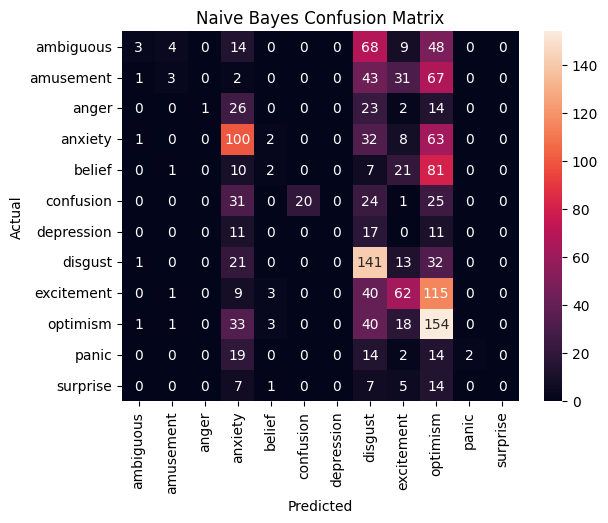

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)
sns.heatmap(cm_nb, annot=True, fmt="d", xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_tfidf)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.35125
Random Forest Classification Report:
               precision    recall  f1-score   support

   ambiguous       0.20      0.07      0.10       146
   amusement       0.39      0.28      0.32       147
       anger       0.43      0.15      0.22        66
     anxiety       0.29      0.51      0.37       206
      belief       0.27      0.15      0.19       122
   confusion       0.75      0.43      0.54       101
  depression       0.50      0.38      0.43        39
     disgust       0.35      0.59      0.44       208
  excitement       0.46      0.34      0.39       230
    optimism       0.30      0.43      0.35       250
       panic       0.43      0.18      0.25        51
    surprise       0.33      0.06      0.10        34

    accuracy                           0.35      1600
   macro avg       0.39      0.30      0.31      1600
weighted avg       0.37      0.35      0.33      1600



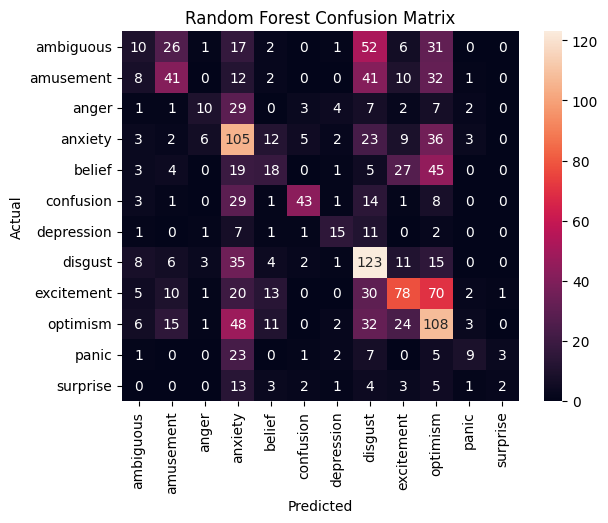

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
sns.heatmap(cm_rf, annot=True, fmt="d", xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can experiment with different k values
knn_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test_tfidf)

# Evaluate
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.2525
KNN Classification Report:
               precision    recall  f1-score   support

   ambiguous       0.15      0.36      0.21       146
   amusement       0.23      0.28      0.25       147
       anger       0.23      0.29      0.26        66
     anxiety       0.29      0.34      0.31       206
      belief       0.22      0.14      0.17       122
   confusion       0.43      0.28      0.34       101
  depression       0.30      0.08      0.12        39
     disgust       0.32      0.30      0.31       208
  excitement       0.28      0.21      0.24       230
    optimism       0.27      0.21      0.23       250
       panic       0.50      0.20      0.28        51
    surprise       0.11      0.03      0.05        34

    accuracy                           0.25      1600
   macro avg       0.28      0.23      0.23      1600
weighted avg       0.27      0.25      0.25      1600



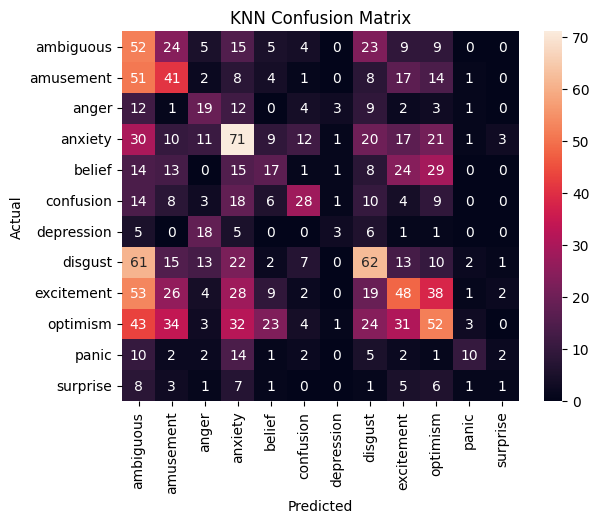

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn_model.classes_)
sns.heatmap(cm_knn, annot=True, fmt="d", xticklabels=knn_model.classes_, yticklabels=knn_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test_tfidf)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.259375
Decision Tree Classification Report:
               precision    recall  f1-score   support

   ambiguous       0.12      0.10      0.11       146
   amusement       0.23      0.20      0.22       147
       anger       0.24      0.18      0.21        66
     anxiety       0.24      0.28      0.26       206
      belief       0.15      0.17      0.16       122
   confusion       0.49      0.48      0.48       101
  depression       0.26      0.15      0.19        39
     disgust       0.32      0.36      0.34       208
  excitement       0.32      0.29      0.30       230
    optimism       0.23      0.26      0.25       250
       panic       0.27      0.27      0.27        51
    surprise       0.16      0.12      0.14        34

    accuracy                           0.26      1600
   macro avg       0.25      0.24      0.24      1600
weighted avg       0.26      0.26      0.26      1600



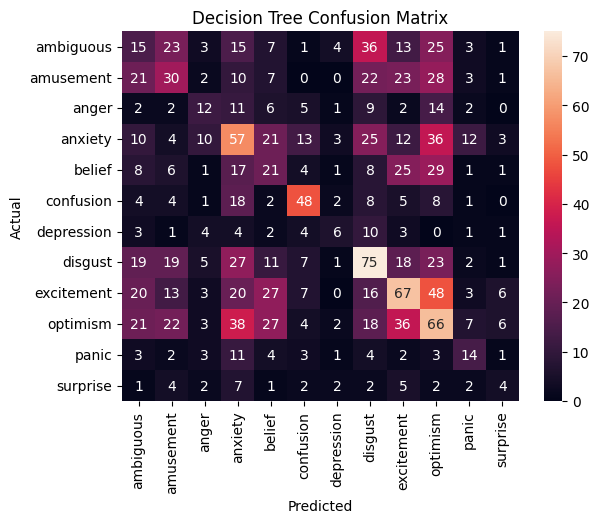

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt, labels=dt_model.classes_)
sns.heatmap(cm_dt, annot=True, fmt="d", xticklabels=dt_model.classes_, yticklabels=dt_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()


In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test_tfidf)

# Evaluate
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.3225
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

   ambiguous       0.26      0.10      0.15       146
   amusement       0.35      0.25      0.29       147
       anger       0.31      0.23      0.26        66
     anxiety       0.31      0.33      0.32       206
      belief       0.20      0.16      0.18       122
   confusion       0.61      0.48      0.53       101
  depression       0.26      0.26      0.26        39
     disgust       0.35      0.47      0.40       208
  excitement       0.50      0.35      0.41       230
    optimism       0.25      0.46      0.33       250
       panic       0.24      0.20      0.22        51
    surprise       0.11      0.09      0.10        34

    accuracy                           0.32      1600
   macro avg       0.31      0.28      0.29      1600
weighted avg       0.34      0.32      0.32      1600



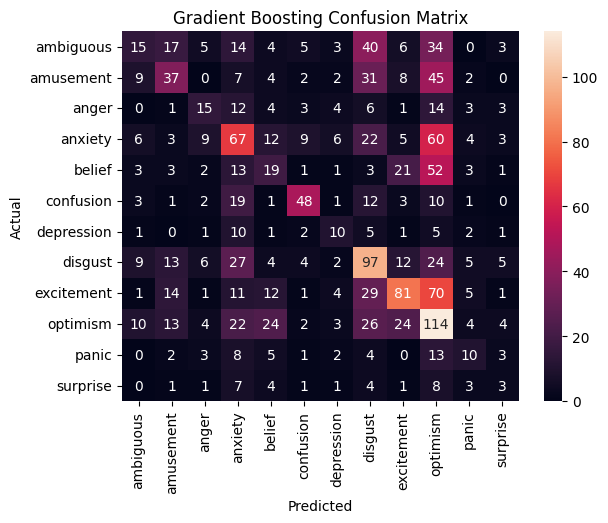

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_gb = confusion_matrix(y_test, y_pred_gb, labels=gb_model.classes_)
sns.heatmap(cm_gb, annot=True, fmt="d", xticklabels=gb_model.classes_, yticklabels=gb_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()


In [20]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the model
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_ada = ada_model.predict(X_test_tfidf)

# Evaluate
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("AdaBoost Classification Report:\n", classification_report(y_test, y_pred_ada))



AdaBoost Accuracy: 0.263125
AdaBoost Classification Report:
               precision    recall  f1-score   support

   ambiguous       0.00      0.00      0.00       146
   amusement       0.50      0.01      0.01       147
       anger       0.00      0.00      0.00        66
     anxiety       0.14      0.14      0.14       206
      belief       0.00      0.00      0.00       122
   confusion       0.86      0.43      0.57       101
  depression       0.00      0.00      0.00        39
     disgust       0.31      0.55      0.39       208
  excitement       0.50      0.30      0.37       230
    optimism       0.20      0.66      0.31       250
       panic       0.00      0.00      0.00        51
    surprise       0.00      0.00      0.00        34

    accuracy                           0.26      1600
   macro avg       0.21      0.17      0.15      1600
weighted avg       0.26      0.26      0.21      1600



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


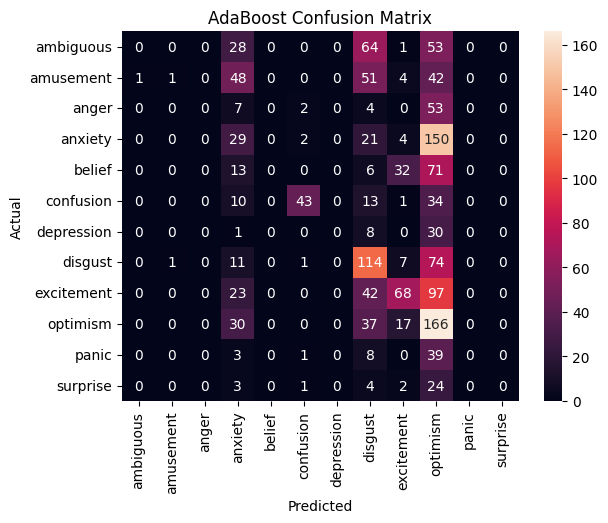

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_ada = confusion_matrix(y_test, y_pred_ada, labels=ada_model.classes_)
sns.heatmap(cm_ada, annot=True, fmt="d", xticklabels=ada_model.classes_, yticklabels=ada_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")
plt.show()


In [28]:
pip install tensorflow


In [37]:
!pip install tensorflow pandas scikit-learn


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the dataset
df = pd.read_csv("processed_stockemo.csv")

# Use correct column names from your screenshot
texts = df['processed']               # Preprocessed text
labels = df['senti_label']            # Column name is 'sent1_label', not 'sent_label'

# Encode sentiment labels (e.g., Bullish/Bearish) to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

# Tokenize the text
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

# Pad sequences
padded_sequences = pad_sequences(sequences, padding='post', maxlen=100)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)




In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Vocabulary size
vocab_size = 10000
embedding_dim = 100
max_length = 100

# CNN with 3 layers
model_3 = Sequential([Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
            Dense(10, activation='relu'),
                Dense(1, activation='sigmoid') ])
model_3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_3.summary()

# Train
history_3 = model_3.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 43s 40ms/step - accuracy: 0.8661 - loss: 0.3482 - val_accuracy: 0.8804 - val_loss: 0.2877
Epoch 2/5
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.9009 - loss: 0.2385 - val_accuracy: 0.8851 - val_loss: 0.3043
Epoch 3/5
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.9408 - loss: 0.1554 - val_accuracy: 0.8796 - val_loss: 0.3443
Epoch 4/5
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.9756 - loss: 0.0769 - val_accuracy: 0.8725 - val_loss: 0.4357
Epoch 5/5
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.9905 - loss: 0.0320 - val_accuracy: 0.8684 - val_loss: 0.5792


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization

vocab_size = 10000
embedding_dim = 100
max_length = 100

# CNN with 5 layers
model_5 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),

            Conv1D(128, 5, activation='relu'),
                BatchNormalization(),
                    Dropout(0.3),

                        Conv1D(64, 3, activation='relu'),
                            GlobalMaxPooling1D(),

                                Dense(64, activation='relu'),
                                    Dropout(0.3),

                                            Dense(1, activation='sigmoid')  # Binary classification
                                            ])

model_5.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_5.summary()

                                            # Train
history_5 = model_5.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 62s 58ms/step - accuracy: 0.8685 - loss: 0.3611 - val_accuracy: 0.8791 - val_loss: 0.2911
Epoch 2/5
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.8929 - loss: 0.2627 - val_accuracy: 0.8837 - val_loss: 0.2940
Epoch 3/5
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 60s 60ms/step - accuracy: 0.9213 - loss: 0.1968 - val_accuracy: 0.8838 - val_loss: 0.3103
Epoch 4/5
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.9444 - loss: 0.1445 - val_accuracy: 0.8813 - val_loss: 0.3515
Epoch 5/5
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 85s 60ms/step - accuracy: 0.9607 - loss: 0.1045 - val_accuracy: 0.8768 - val_loss: 0.4174
